In [11]:
import json
import re

# ================
# 1. TREE DATA
# ================
tree_json = """
[
  {"id":"START","type":"start","text":"Good evening. Let’s take a structured look at your day.","next":"A1_Q1"},

  {"id":"A1_Q1","type":"question",
   "text":"When things moved off track today, where did your attention go first?",
   "options":["Fixing it","Explaining it","Who caused it","Waiting it out"],
   "next":"A1_D1"},

  {"id":"A1_D1","type":"decision","rules":{
    "Fixing it":"A1_Q2_INT",
    "Explaining it":"A1_Q2_EXT",
    "Who caused it":"A1_Q2_EXT",
    "Waiting it out":"A1_Q2_EXT"
  }},

  {"id":"A1_Q2_INT","type":"question",
   "text":"When you stepped in to fix things, what guided your action?",
   "options":["What I could control","Past experience","Team input","Trial and error"],
   "signal":"axis1:internal",
   "next":"A1_R1_INT"},

  {"id":"A1_Q2_EXT","type":"question",
   "text":"When things felt out of your hands, what did you find yourself doing?",
   "options":["Waiting for direction","Working around constraints","Getting frustrated","Escalating it"],
   "signal":"axis1:external",
   "next":"A1_R1_EXT"},

  {"id":"A1_R1_INT","type":"reflection",
   "text":"You moved toward action — focusing on what you could influence. That’s a signal of agency.",
   "next":"A1_Q3"},

  {"id":"A1_R1_EXT","type":"reflection",
   "text":"It felt shaped by external forces. That’s real — but even here, your response still carried choice.",
   "next":"A1_Q3"},

  {"id":"A1_Q3","type":"question",
   "text":"Looking back, where did you actually have more control than it seemed?",
   "options":["My reaction","My preparation","My communication","I don’t see it yet"],
   "next":"A1_R2"},

  {"id":"A1_R2","type":"reflection",
   "text":"That gap — between what happened and what you could influence — is where growth sits.",
   "next":"BRIDGE_1"},

  {"id":"BRIDGE_1","type":"bridge",
   "text":"Let’s shift from control → to contribution. When pressure shows up, what do you give?",
   "next":"A2_Q1"},

  {"id":"A2_Q1","type":"question",
   "text":"In your most important interaction today, what was your underlying intent?",
   "options":["Get it done","Add value","Avoid extra work","Protect my time"],
   "next":"A2_D1"},

  {"id":"A2_D1","type":"decision","rules":{
    "Add value":"A2_Q2_CONT",
    "Get it done":"A2_Q2_NEUTRAL",
    "Avoid extra work":"A2_Q2_ENT",
    "Protect my time":"A2_Q2_ENT"
  }},

  {"id":"A2_Q2_CONT","type":"question",
   "text":"When you went beyond expectations, what drove that?",
   "options":["Helping someone","Improving outcome","Team success","Ownership"],
   "signal":"axis2:contribution",
   "next":"A2_R1_CONT"},

  {"id":"A2_Q2_ENT","type":"question",
   "text":"When you held back, what felt most true?",
   "options":["Not my responsibility","Others should step up","I was drained","No recognition anyway"],
   "signal":"axis2:entitlement",
   "next":"A2_R1_ENT"},

  {"id":"A2_Q2_NEUTRAL","type":"question",
   "text":"Doing what was required — what shaped that choice?",
   "options":["Clear scope","Time pressure","Energy levels","Expectations"],
   "next":"A2_R1_NEUTRAL"},

  {"id":"A2_R1_CONT","type":"reflection",
   "text":"You leaned into contribution — extending beyond your role. That builds long-term value.",
   "next":"A2_Q3"},

  {"id":"A2_R1_ENT","type":"reflection",
   "text":"Holding back can protect energy — but it can also quietly reinforce distance from impact.",
   "next":"A2_Q3"},

  {"id":"A2_R1_NEUTRAL","type":"reflection",
   "text":"You stayed within defined boundaries. Stable — but worth noticing where you might stretch.",
   "next":"A2_Q3"},

  {"id":"A2_Q3","type":"question",
   "text":"Where did you contribute more than expected today?",
   "options":["Helping someone","Improving process","Sharing knowledge","I didn’t"],
   "next":"A2_R2"},

  {"id":"A2_R2","type":"reflection",
   "text":"Contribution isn’t always visible — but it shapes how your day compounds over time.",
   "next":"BRIDGE_2"},

  {"id":"BRIDGE_2","type":"bridge",
   "text":"Now let’s widen the lens — beyond you, into others.",
   "next":"A3_Q1"},

  {"id":"A3_Q1","type":"question",
   "text":"When you think about today’s biggest challenge, who comes to mind?",
   "options":["Just me","My team","A colleague","The end user"],
   "next":"A3_D1"},

  {"id":"A3_D1","type":"decision","rules":{
    "Just me":"A3_Q2_SELF",
    "My team":"A3_Q2_MID",
    "A colleague":"A3_Q2_OTH",
    "The end user":"A3_Q2_OTH"
  }},

  {"id":"A3_Q2_SELF","type":"question",
   "text":"When focused on yourself, what dominated your thinking?",
   "options":["Deadlines","Stress","Performance","Clarity"],
   "signal":"axis3:self",
   "next":"A3_R1_SELF"},

  {"id":"A3_Q2_MID","type":"question",
   "text":"Balancing self and others — what stood out?",
   "options":["Coordination","Shared pressure","Support","Alignment"],
   "next":"A3_R1_MID"},

  {"id":"A3_Q2_OTH","type":"question",
   "text":"Focusing outward — what mattered most?",
   "options":["Helping","Understanding","Solving impact","Empathy"],
   "signal":"axis3:other",
   "next":"A3_R1_OTH"},

  {"id":"A3_R1_SELF","type":"reflection",
   "text":"Your focus narrowed inward. That often happens under pressure — but it limits perspective.",
   "next":"A3_Q3"},

  {"id":"A3_R1_MID","type":"reflection",
   "text":"You balanced perspectives — holding both your needs and others’ in view.",
   "next":"A3_Q3"},

  {"id":"A3_R1_OTH","type":"reflection",
   "text":"You expanded outward — connecting your work to others. That builds meaning.",
   "next":"A3_Q3"},

  {"id":"A3_Q3","type":"question",
   "text":"In conversations, how did you show up most often?",
   "options":["Listening deeply","Waiting to respond","Solving quickly","Redirecting"],
   "next":"A3_R2"},

  {"id":"A3_R2","type":"reflection",
   "text":"How you show up in moments defines your radius more than your intentions.",
   "next":"SUMMARY"},

  {"id":"SUMMARY","type":"summary"}
]
"""

tree_data = json.loads(tree_json)

# ============================
# 2. ENGINE
# ============================
class ReflectionAgent:
    def __init__(self, data):
        self.nodes = {n["id"]: n for n in data}
        self.answers = {}
        self.signals = {
            "axis1": {"internal":0,"external":0},
            "axis2": {"contribution":0,"entitlement":0},
            "axis3": {"self":0,"other":0}
        }

    def apply_signal(self, signal):
        if not signal: return
        axis, val = signal.split(":")
        self.signals[axis][val] += 1

    def interpolate(self, text):
        for k,v in self.answers.items():
            text = text.replace(f"{{{k}}}", v)
        return text

    def dominant(self, axis):
        return max(self.signals[axis], key=self.signals[axis].get)

    def summary(self):
        a1 = self.dominant("axis1")
        a2 = self.dominant("axis2")
        a3 = self.dominant("axis3")

        print("\n--- FINAL REFLECTION ---\n")

        print(f"Today, you leaned toward **{a1} agency**, **{a2} contribution**, and a **{a3}-focused perspective**.\n")

        print("There’s a pattern here:")

        if a1 == "external":
            print("- At times, things felt outside your control.")
        else:
            print("- You actively shaped outcomes.")

        if a2 == "entitlement":
            print("- Your energy pulled toward protecting what you deserve.")
        else:
            print("- You leaned toward giving value.")

        if a3 == "self":
            print("- Under pressure, your focus narrowed inward.")
        else:
            print("- You expanded your thinking toward others.")

        print("\nSmall shifts in any one of these can change how your entire day feels tomorrow.\n")

    def run(self):
        current = "START"

        while current:
            node = self.nodes[current]

            if node["type"] in ["start","bridge","reflection"]:
                print("\n" + self.interpolate(node["text"]))
                self.apply_signal(node.get("signal"))
                if node["type"]=="reflection":
                    input("\n[Enter]")
                current = node.get("next")

            elif node["type"]=="question":
                print("\n" + node["text"])
                for i,opt in enumerate(node["options"],1):
                    print(f"{i}. {opt}")

                choice = int(input("\nChoice: ")) - 1
                ans = node["options"][choice]

                self.answers[node["id"]] = ans
                self.apply_signal(node.get("signal"))

                current = node.get("next")

            elif node["type"]=="decision":
                last = list(self.answers.values())[-1]
                current = node["rules"][last]

            elif node["type"]=="summary":
                self.summary()
                break

# ============================
# RUN
# ============================
if __name__ == "__main__":
    agent = ReflectionAgent(tree_data)
    agent.run()


Good evening. Let’s take a structured look at your day.

When things moved off track today, where did your attention go first?
1. Fixing it
2. Explaining it
3. Who caused it
4. Waiting it out

Choice: 1

When you stepped in to fix things, what guided your action?
1. What I could control
2. Past experience
3. Team input
4. Trial and error

Choice: 2

You moved toward action — focusing on what you could influence. That’s a signal of agency.

[Enter]

Looking back, where did you actually have more control than it seemed?
1. My reaction
2. My preparation
3. My communication
4. I don’t see it yet

Choice: 1

That gap — between what happened and what you could influence — is where growth sits.

[Enter]

Let’s shift from control → to contribution. When pressure shows up, what do you give?

In your most important interaction today, what was your underlying intent?
1. Get it done
2. Add value
3. Avoid extra work
4. Protect my time

Choice: 3

When you held back, what felt most true?
1. Not my 

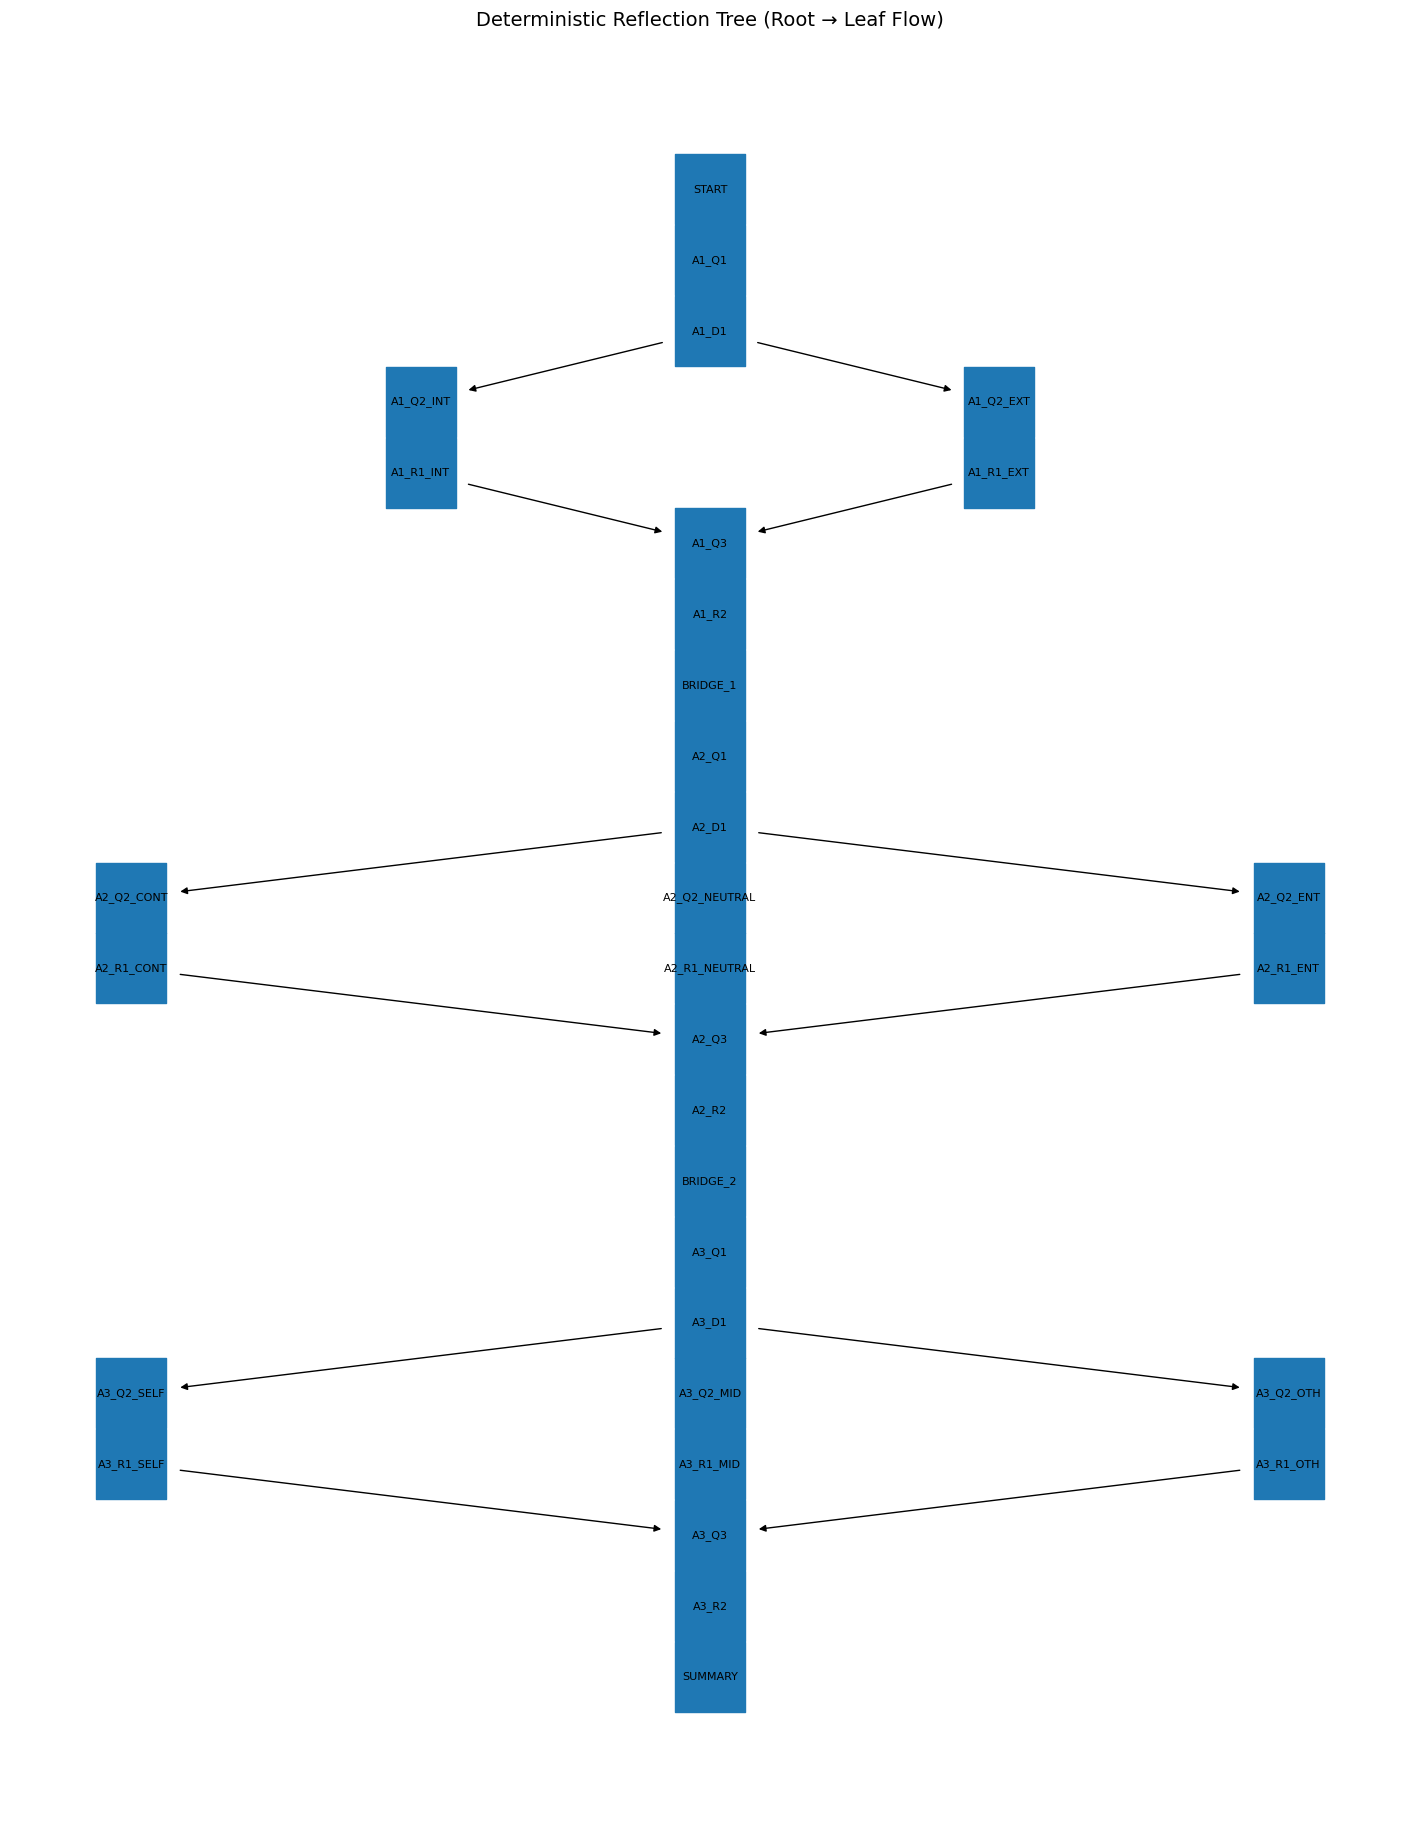

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

def build_graph():
    G = nx.DiGraph()

    # ---------- EDGES ----------
    edges = [
        ("START", "A1_Q1"),
        ("A1_Q1", "A1_D1"),

        ("A1_D1", "A1_Q2_INT"),
        ("A1_D1", "A1_Q2_EXT"),

        ("A1_Q2_INT", "A1_R1_INT"),
        ("A1_Q2_EXT", "A1_R1_EXT"),

        ("A1_R1_INT", "A1_Q3"),
        ("A1_R1_EXT", "A1_Q3"),

        ("A1_Q3", "A1_R2"),
        ("A1_R2", "BRIDGE_1"),

        ("BRIDGE_1", "A2_Q1"),
        ("A2_Q1", "A2_D1"),

        ("A2_D1", "A2_Q2_CONT"),
        ("A2_D1", "A2_Q2_NEUTRAL"),
        ("A2_D1", "A2_Q2_ENT"),

        ("A2_Q2_CONT", "A2_R1_CONT"),
        ("A2_Q2_NEUTRAL", "A2_R1_NEUTRAL"),
        ("A2_Q2_ENT", "A2_R1_ENT"),

        ("A2_R1_CONT", "A2_Q3"),
        ("A2_R1_NEUTRAL", "A2_Q3"),
        ("A2_R1_ENT", "A2_Q3"),

        ("A2_Q3", "A2_R2"),
        ("A2_R2", "BRIDGE_2"),

        ("BRIDGE_2", "A3_Q1"),
        ("A3_Q1", "A3_D1"),

        ("A3_D1", "A3_Q2_SELF"),
        ("A3_D1", "A3_Q2_MID"),
        ("A3_D1", "A3_Q2_OTH"),

        ("A3_Q2_SELF", "A3_R1_SELF"),
        ("A3_Q2_MID", "A3_R1_MID"),
        ("A3_Q2_OTH", "A3_R1_OTH"),

        ("A3_R1_SELF", "A3_Q3"),
        ("A3_R1_MID", "A3_Q3"),
        ("A3_R1_OTH", "A3_Q3"),

        ("A3_Q3", "A3_R2"),
        ("A3_R2", "SUMMARY")
    ]

    G.add_edges_from(edges)
    return G


def get_positions():
    pos = {}

    # Layer by layer (y decreases downward)
    layers = [
        ["START"],

        ["A1_Q1"],
        ["A1_D1"],
        ["A1_Q2_INT", "A1_Q2_EXT"],
        ["A1_R1_INT", "A1_R1_EXT"],
        ["A1_Q3"],
        ["A1_R2"],
        ["BRIDGE_1"],

        ["A2_Q1"],
        ["A2_D1"],
        ["A2_Q2_CONT", "A2_Q2_NEUTRAL", "A2_Q2_ENT"],
        ["A2_R1_CONT", "A2_R1_NEUTRAL", "A2_R1_ENT"],
        ["A2_Q3"],
        ["A2_R2"],
        ["BRIDGE_2"],

        ["A3_Q1"],
        ["A3_D1"],
        ["A3_Q2_SELF", "A3_Q2_MID", "A3_Q2_OTH"],
        ["A3_R1_SELF", "A3_R1_MID", "A3_R1_OTH"],
        ["A3_Q3"],
        ["A3_R2"],
        ["SUMMARY"]
    ]

    y = 0
    for layer in layers:
        x_spacing = 1
        start_x = - (len(layer) - 1) / 2

        for i, node in enumerate(layer):
            pos[node] = (start_x + i * x_spacing, -y)

        y += 1

    return pos


def draw_graph():
    G = build_graph()
    pos = get_positions()

    plt.figure(figsize=(14, 18))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2500,
        font_size=8,
        node_shape="s"
    )

    plt.title("Deterministic Reflection Tree (Root → Leaf Flow)", fontsize=14)
    plt.show()


if __name__ == "__main__":
    draw_graph()